In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from arch import arch_model
from scipy import stats


In [2]:

sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 100
rng = np.random.default_rng(42)

# --- Load & clean ---
df_raw = pd.read_csv('../data/spiff_data-2.csv').drop(columns=['Unnamed: 0']).set_index('day')
series_cols = df_raw.columns.tolist()
df = df_raw.replace(1000, np.nan)
df_full = df.loc[:df.dropna(how='all').index.max()]           # strip trailing all-NaN padding
df_common = df_full.loc[1449:].dropna()                       # gap-free window

# Log-returns (same convention as task 1; log makes the endpoint constraint linear)
log_ret_full = np.log(df_full / df_full.shift(1))
log_ret_common = np.log(df_common / df_common.shift(1)).dropna()

def find_nan_gaps(s, min_len=1):
    isn = s.isna().values
    out, i, n = [], 0, len(isn)
    while i < n:
        if isn[i]:
            j = i
            while j < n and isn[j]: j += 1
            if j - i >= min_len:
                out.append((s.index[i], s.index[j-1], j-i))
            i = j
        else:
            i += 1
    return out

# Only the *structural* 50-day gaps (not the scattered 1-day 1000-sentinels)
structural_gaps = {c: [(s, e, l) for s, e, l in find_nan_gaps(df_full[c], min_len=2)]
                   for c in series_cols}
print('Structural gaps (start, end, length) per series:')
for c in series_cols:
    print(f'  {c:<14} {structural_gaps[c]}')
print(f'\nlog_ret_full: {log_ret_full.shape},  log_ret_common: {log_ret_common.shape}')

Structural gaps (start, end, length) per series:
  gurkor         [(199, 248, 50)]
  guitars        [(399, 448, 50)]
  slingshots     [(599, 648, 50)]
  stocks         [(799, 848, 50)]
  sugar          [(999, 1048, 50)]
  water          [(1199, 1248, 50)]
  tranquillity   [(1399, 1448, 50)]

log_ret_full: (5256, 7),  log_ret_common: (3804, 7)


In [3]:
def apply_endpoint_constraint(mean_gap, var_gap, target_sum):
    """Condition N(mean, diag(var)) on 1^T r = target_sum. Returns (mean', var')."""
    var_gap = np.asarray(var_gap, dtype=float)
    mean_gap = np.asarray(mean_gap, dtype=float)
    v_sum = var_gap.sum()
    if v_sum <= 0:
        return mean_gap, var_gap
    delta = target_sum - mean_gap.sum()
    w = var_gap / v_sum
    new_mean = mean_gap + w * delta
    new_var  = var_gap - var_gap**2 / v_sum
    return new_mean, new_var

In [4]:
def _fit_t(sample, ci=0.95):
    """Fit Student-t by MLE only to get the df (tail thickness). Return
    (sigma, q, df) where:
      - sigma is the *sample* std of the residuals (finite and well-defined
        even when df is small enough that the t variance diverges),
      - q is the two-sided ci-quantile of the fitted t.
    This widens bands relative to Normal in proportion to tail heaviness,
    without inflating the scale itself."""
    s = np.asarray(sample, dtype=float)
    s = s[np.isfinite(s)]
    df, _, _ = stats.t.fit(s)
    alpha = (1 - ci) / 2
    sigma = float(s.std(ddof=1))
    q = float(stats.t.ppf(1 - alpha, df))
    return sigma, q, float(df)


def brownian_bridge_baseline(price_series, gap_start, gap_end,
                             train_returns, ci=0.95):
    """Deterministic pinned mean + analytic bridge band.
    Var(logP_t) = sigma^2 * t*(N-t)/N  (standard Brownian-bridge variance),
    where sigma is the Student-t std of one log-return increment."""
    logP0 = float(np.log(price_series.loc[gap_start - 1]))
    logP1 = float(np.log(price_series.loc[gap_end + 1]))
    N = gap_end - gap_start + 2
    t = np.arange(1, N)
    mean_path = logP0 + (logP1 - logP0) * t / N

    sigma, q, df = _fit_t(train_returns.dropna().values, ci=ci)
    var_path = sigma**2 * t * (N - t) / N
    half = q * np.sqrt(var_path)

    return pd.DataFrame({
        'day': np.arange(gap_start, gap_end + 1),
        'logP_mean': mean_path,
        'logP_std':  np.sqrt(var_path),
        'logP_lo':   mean_path - half,
        'logP_hi':   mean_path + half,
        'resid_dist': f't(df={df:.1f})',
    }).set_index('day')


def cross_section_ols_baseline(target_series, log_ret_train, log_ret_gap_observed,
                               price_series, gap_start, gap_end, ci=0.95):
    """OLS on contemporaneous returns. Mean path is endpoint-corrected via
    apply_endpoint_constraint; band width uses Student-t std + t-quantile."""
    others = [c for c in log_ret_train.columns if c != target_series]
    X = log_ret_train[others].values
    y = log_ret_train[target_series].values
    Xd = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    res = y - Xd @ beta

    sigma, q, df = _fit_t(res, ci=ci)

    X_gap = log_ret_gap_observed[others].values
    ret_hat = np.column_stack([np.ones(len(X_gap)), X_gap]) @ beta
    vr = np.full(len(ret_hat), sigma**2)

    logP0 = float(np.log(price_series.loc[gap_start - 1]))
    logP1 = float(np.log(price_series.loc[gap_end + 1]))
    mu_c, _ = apply_endpoint_constraint(ret_hat, vr, logP1 - logP0)
    cum_mu = np.cumsum(mu_c)[:-1]
    # Pinned variance: under the constraint sum(r) = target with iid variance v,
    # Var(cumsum_k) = v * k*(N-k)/N (Brownian-bridge variance). The endpoint
    # constraint induces negative covariance between returns; cumsum of marginal
    # post-constraint variances would miss that and give a non-pinned band.
    N = len(ret_hat)
    k = np.arange(1, N)
    var_path = sigma**2 * k * (N - k) / N
    mean_path = logP0 + cum_mu
    half = q * np.sqrt(var_path)

    return pd.DataFrame({
        'day': np.arange(gap_start, gap_end + 1),
        'logP_mean': mean_path,
        'logP_std':  np.sqrt(var_path),
        'logP_lo':   mean_path - half,
        'logP_hi':   mean_path + half,
        'resid_dist': f't(df={df:.1f})',
    }).set_index('day')


# --- Run validation ---
GAP_LEN = 30
mask_starts = [1700, 2600, 3200, 3900, 5000]
val_results = []

for gs in mask_starts:
    ge = gs + GAP_LEN - 1
    for tgt in series_cols:
        truth_logP = np.log(df_common.loc[gs:ge, tgt])
        mask_ret_idx = np.arange(gs, ge + 2)
        mask_ret_idx = np.array([d for d in mask_ret_idx if d in log_ret_common.index])
        train_idx = log_ret_common.index.difference(mask_ret_idx)
        log_ret_train = log_ret_common.loc[train_idx]

        bb = brownian_bridge_baseline(df_common[tgt], gs, ge,
                                      train_returns=log_ret_train[tgt])
        cs = cross_section_ols_baseline(tgt, log_ret_train,
                                        log_ret_common.loc[mask_ret_idx],
                                        df_common[tgt], gs, ge)

        def rmse(p): return np.sqrt(np.mean((p['logP_mean'].values - truth_logP.values)**2))
        def cov(p):  return float(np.mean((truth_logP.values >= p['logP_lo'].values) &
                                          (truth_logP.values <= p['logP_hi'].values)))
        val_results.append({
            'gap_start': gs, 'series': tgt,
            'rmse_logP_bridge': rmse(bb), 'rmse_logP_xsect': rmse(cs),
            'cov95_bridge':     cov(bb),  'cov95_xsect':     cov(cs),
            'dist_bridge':      bb['resid_dist'].iloc[0],
            'dist_xsect':       cs['resid_dist'].iloc[0],
        })

val_df = pd.DataFrame(val_results)
print('Validation mean scores across 5 gaps x 7 series:\n')
print(val_df[['rmse_logP_bridge', 'rmse_logP_xsect',
              'cov95_bridge',     'cov95_xsect']].mean().round(4).to_string())
print('\nPer-series mean xsect log-price RMSE:')
print(val_df.groupby('series')['rmse_logP_xsect'].mean().round(4).to_string())


Validation mean scores across 5 gaps x 7 series:

rmse_logP_bridge    0.0227
rmse_logP_xsect     0.0210
cov95_bridge        0.9771
cov95_xsect         0.9838

Per-series mean xsect log-price RMSE:
series
guitars         0.0311
gurkor          0.0055
slingshots      0.0194
stocks          0.0302
sugar           0.0221
tranquillity    0.0315
water           0.0071


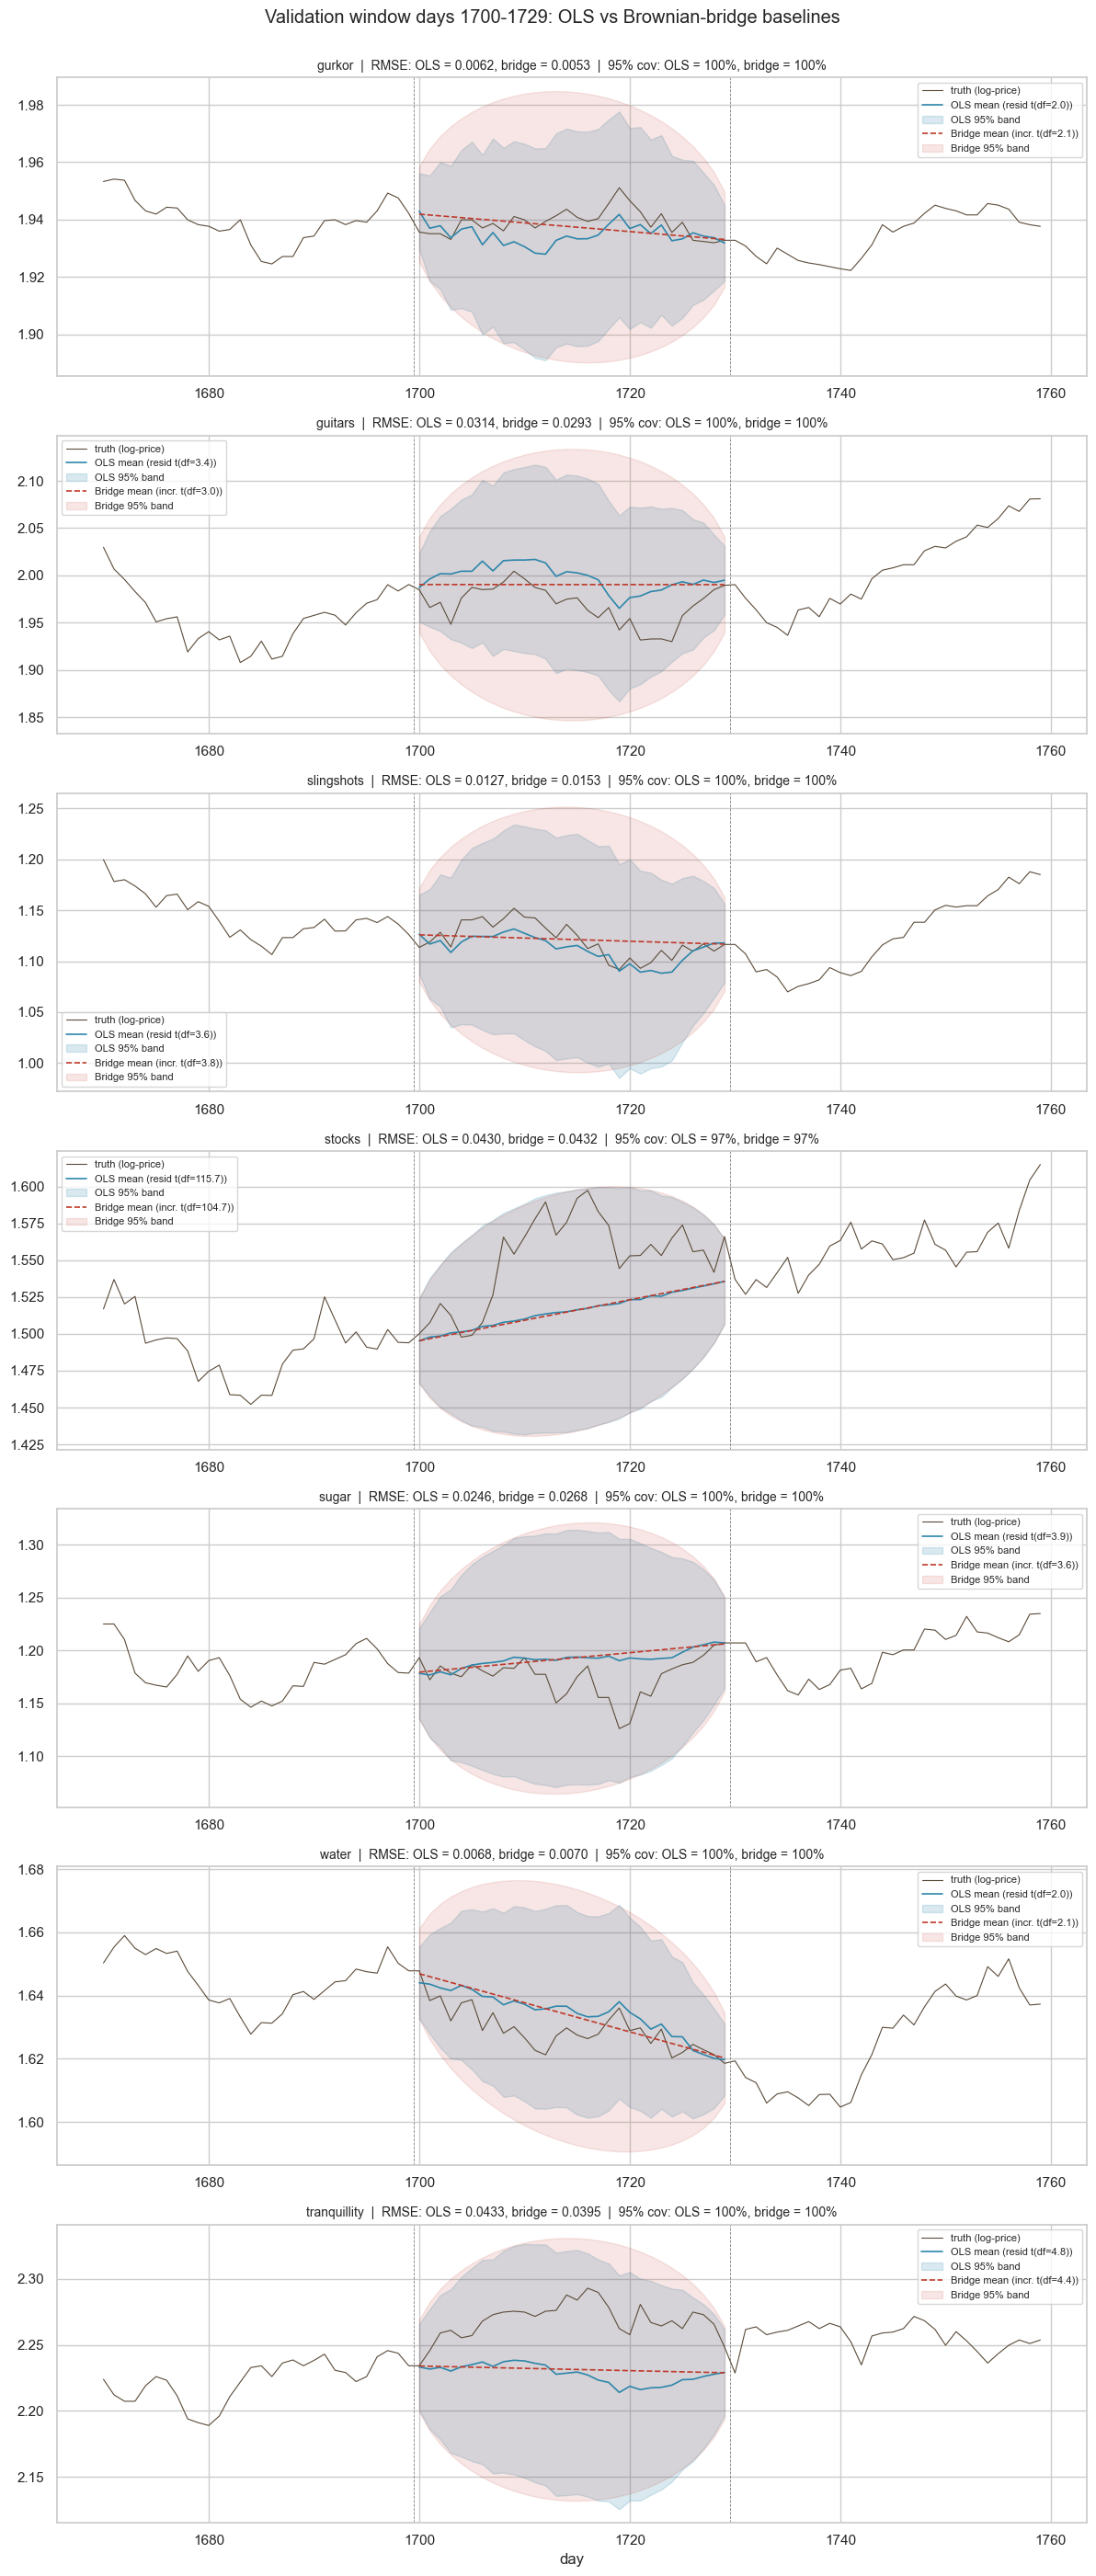

In [5]:
# Pick one safe window and visualise both baselines for every series.
gs_viz = int(rng.choice(mask_starts))
ge_viz = gs_viz + GAP_LEN - 1
PAD = 30

mask_ret_idx_viz = np.arange(gs_viz, ge_viz + 2)
mask_ret_idx_viz = np.array([d for d in mask_ret_idx_viz if d in log_ret_common.index])
train_idx_viz = log_ret_common.index.difference(mask_ret_idx_viz)
log_ret_train_viz = log_ret_common.loc[train_idx_viz]
log_ret_gap_obs_viz = log_ret_common.loc[mask_ret_idx_viz]

viz_ols, viz_bb = {}, {}
for tgt in series_cols:
    viz_ols[tgt] = cross_section_ols_baseline(
        tgt, log_ret_train_viz, log_ret_gap_obs_viz,
        df_common[tgt], gs_viz, ge_viz
    )
    viz_bb[tgt] = brownian_bridge_baseline(
        df_common[tgt], gs_viz, ge_viz,
        train_returns=log_ret_train_viz[tgt]
    )

fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 4 * len(series_cols)),
                         sharex=False)
for ax, tgt in zip(axes, series_cols):
    ols = viz_ols[tgt]
    bb  = viz_bb[tgt]
    ctx_days = np.arange(max(df_common.index.min(), gs_viz - PAD),
                         min(df_common.index.max(), ge_viz + PAD) + 1)
    truth_logP_ctx = np.log(df_common.loc[ctx_days, tgt])

    ax.plot(ctx_days, truth_logP_ctx, color='#5B4B3A', lw=0.8, label='truth (log-price)')

    ax.plot(ols.index, ols['logP_mean'], color='#2E86AB', lw=1.2,
            label=f"OLS mean (resid {ols['resid_dist'].iloc[0]})")
    ax.fill_between(ols.index, ols['logP_lo'], ols['logP_hi'],
                    color='#2E86AB', alpha=0.18, label='OLS 95% band')

    ax.plot(bb.index, bb['logP_mean'], color='#C0392B', lw=1.2, ls='--',
          label=f"Bridge mean (incr. {bb['resid_dist'].iloc[0]})")
    ax.fill_between(bb.index, bb['logP_lo'], bb['logP_hi'],
                   color='#C0392B', alpha=0.12, label='Bridge 95% band')

    ax.axvline(gs_viz - 0.5, color='grey', ls='--', lw=0.6)
    ax.axvline(ge_viz + 0.5, color='grey', ls='--', lw=0.6)

    truth_logP = np.log(df_common.loc[ols.index, tgt].values)
    rmse_ols = np.sqrt(np.mean((ols['logP_mean'].values - truth_logP) ** 2))
    rmse_bb  = np.sqrt(np.mean((bb['logP_mean'].values  - truth_logP) ** 2))
    cov_ols  = np.mean((truth_logP >= ols['logP_lo'].values) & (truth_logP <= ols['logP_hi'].values))
    cov_bb   = np.mean((truth_logP >= bb['logP_lo'].values)  & (truth_logP <= bb['logP_hi'].values))
    ax.set_title(
        f"{tgt}  |  RMSE: OLS = {rmse_ols:.4f}, bridge = {rmse_bb:.4f}  "
        f"|  95% cov: OLS = {cov_ols:.0%}, bridge = {cov_bb:.0%}",
        fontsize=10,
    )
    ax.legend(loc='best', fontsize=8)

axes[-1].set_xlabel('day')
fig.suptitle(f'Validation window days {gs_viz}-{ge_viz}: OLS vs Brownian-bridge baselines',
             y=1.00)
fig.tight_layout()
plt.show()


In [6]:
# --- Fill the actual dataset ---
# 1) Sentinel days (the 5 isolated 1000 -> NaN points): mean of immediate neighbours.
# 2) Each series' 50-day structural gap: OLS cross-section baseline.
#    Training: log_ret_common (gap-free window, day 1449+, all 7 series observed).
#    Regressors at gap days: the other 6 series' observed log-returns (gaps are disjoint).

SENTINEL_DAYS = [36, 1194, 2836, 3430, 4118]

df_filled = df_full.copy()
for d in SENTINEL_DAYS:
    for c in series_cols:
        df_filled.loc[d, c] = 0.5 * (df_full.loc[d - 1, c] + df_full.loc[d + 1, c])

# Recompute log-returns on the sentinel-cleaned panel. The 50-day structural
# gaps are still NaN here; that's fine — we only need the OTHER series' returns
# at those days (and they're observed because the gaps are disjoint per series).
log_ret_filled = np.log(df_filled / df_filled.shift(1))

# Locate each series' single structural gap (length >= 2).
structural_gaps = {}
for c in series_cols:
    runs = []
    isn = df_filled[c].isna().values
    days = df_filled.index.values
    i, n = 0, len(isn)
    while i < n:
        if isn[i]:
            j = i
            while j < n and isn[j]: j += 1
            if j - i >= 2:
                runs.append((int(days[i]), int(days[j - 1]), j - i))
            i = j
        else:
            i += 1
    assert len(runs) == 1, f'{c}: expected one structural gap, got {runs}'
    structural_gaps[c] = runs[0]

gap_imputations = {}
print('Filling structural gaps with OLS cross-section baseline:\n')
for c in series_cols:
    gs, ge, gl = structural_gaps[c]
    ret_days = np.arange(gs, ge + 2)        # gap returns + the return into the post-gap anchor
    gap_obs = log_ret_filled.loc[ret_days]  # the OTHER 6 series are observed here
    imp = cross_section_ols_baseline(
        target_series=c,
        log_ret_train=log_ret_common,
        log_ret_gap_observed=gap_obs,
        price_series=df_filled[c],          # only needs the two anchor prices
        gap_start=gs,
        gap_end=ge,
    )
    gap_imputations[c] = imp
    # Write the imputed price path into df_filled
    df_filled.loc[imp.index, c] = np.exp(imp['logP_mean'].values)
    print(f'  {c:<14} gap days {gs}-{ge}  ({gl} days)  resid={imp["resid_dist"].iloc[0]}')

print(f'\nRemaining NaN count per series after filling:')
print(df_filled.isna().sum().to_string())

OUT_PATH = '../data/spiff_data-2_filled.csv'
df_filled.to_csv(OUT_PATH)
print(f'\nSaved filled dataset to {OUT_PATH}  (shape {df_filled.shape})')


Filling structural gaps with OLS cross-section baseline:

  gurkor         gap days 199-248  (50 days)  resid=t(df=4.5)
  guitars        gap days 399-448  (50 days)  resid=t(df=3.4)
  slingshots     gap days 599-648  (50 days)  resid=t(df=3.6)
  stocks         gap days 799-848  (50 days)  resid=t(df=118.4)
  sugar          gap days 999-1048  (50 days)  resid=t(df=3.9)
  water          gap days 1199-1248  (50 days)  resid=t(df=2.0)
  tranquillity   gap days 1399-1448  (50 days)  resid=t(df=4.8)

Remaining NaN count per series after filling:
gurkor          0
guitars         0
slingshots      0
stocks          0
sugar           0
water           0
tranquillity    0

Saved filled dataset to ../data/spiff_data-2_filled.csv  (shape (5256, 7))


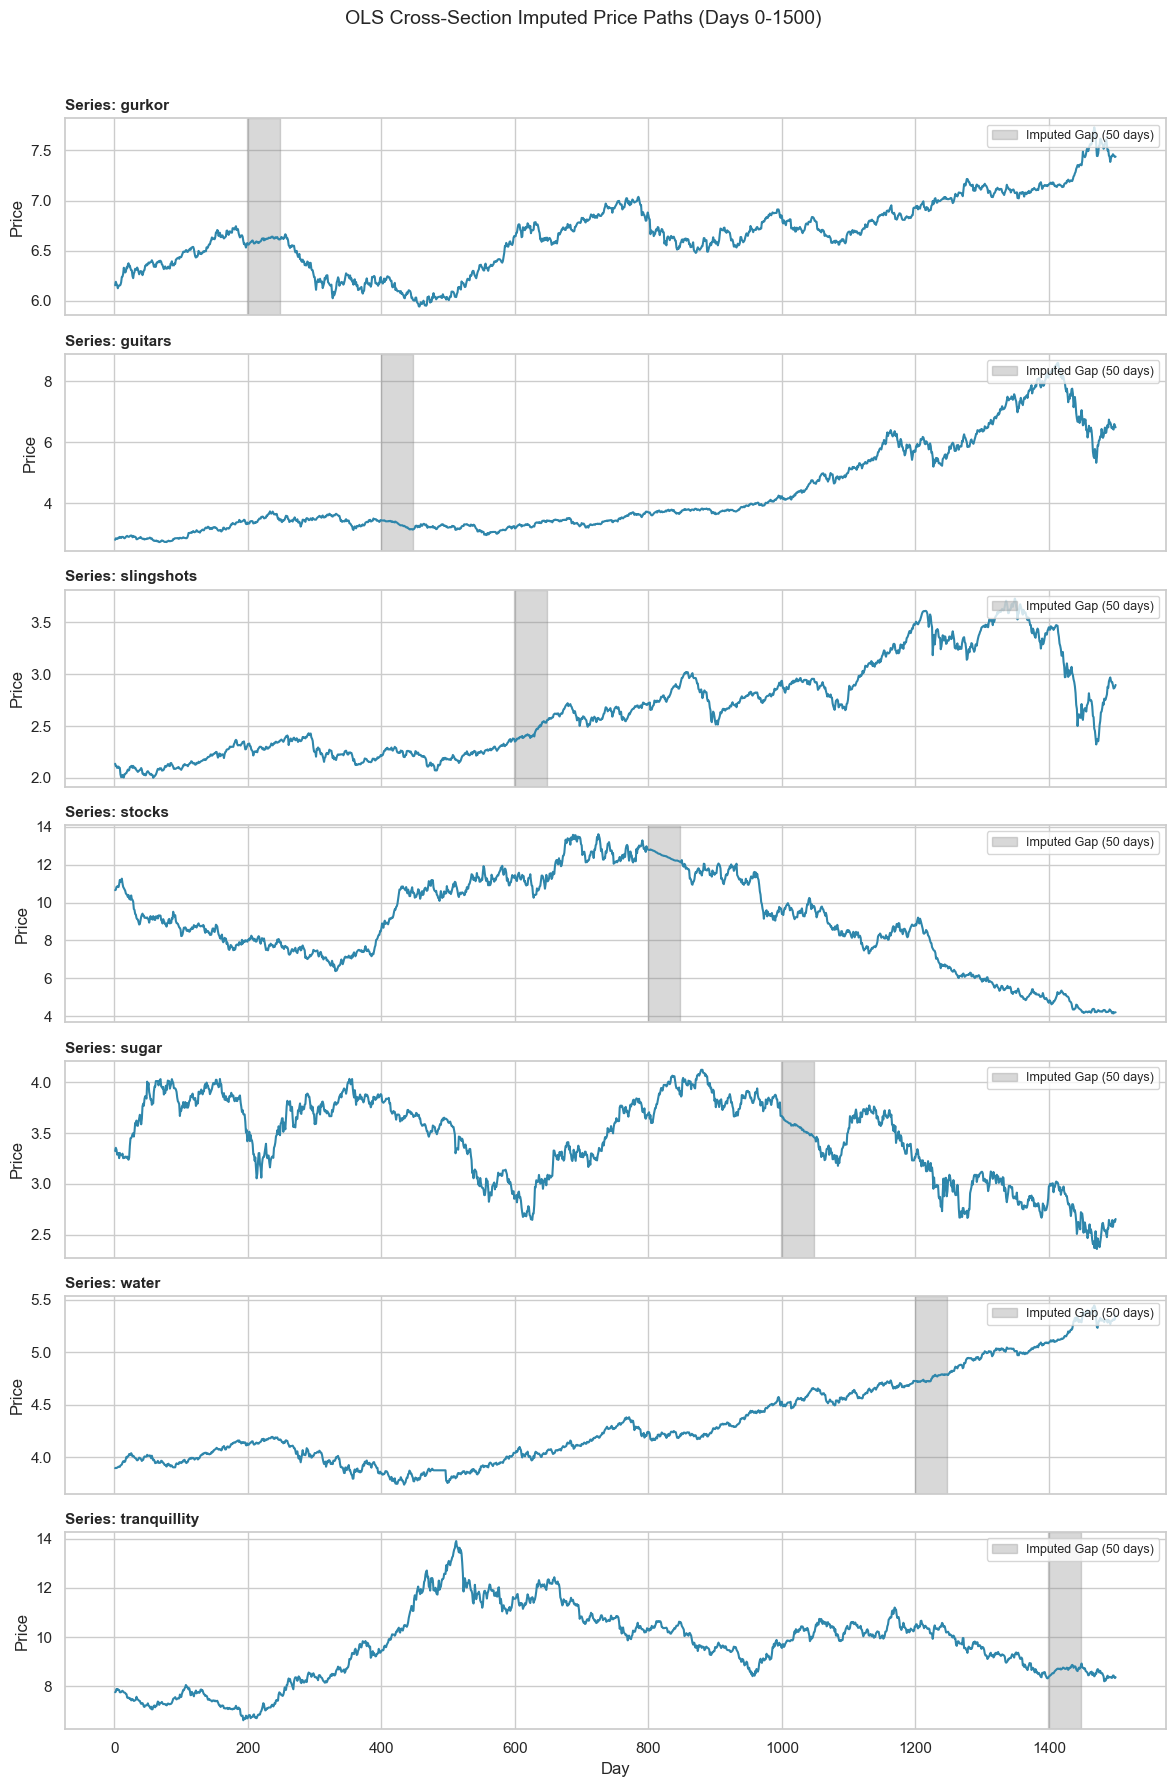

In [7]:
import matplotlib.pyplot as plt

# Create a grid of subplots (7 rows, 1 column)
fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 2.5 * len(series_cols)), sharex=True)

for ax, c in zip(axes, series_cols):
    # CORRECTED UNPACKING: structural_gaps[c] is directly the tuple (start, end, length)
    gs, ge, gl = structural_gaps[c]
    
    # Plot the data (up to day 1500)
    ax.plot(df_filled.index[:1500], df_filled[c].iloc[:1500], color='#2E86AB', lw=1.5)
    
    # Shade the gap region if it falls within the first 1500 days
    if gs <= 1500:
        ax.axvspan(gs, min(ge, 1500), color='grey', alpha=0.3, label=f'Imputed Gap ({gl} days)')
        
    # Clean up labels per subplot
    ax.set_title(f'Series: {c}', loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price')
    
    # Only show the legend if a gap is actually plotted in this window
    if gs <= 1500:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Day')
fig.suptitle('OLS Cross-Section Imputed Price Paths (Days 0-1500)', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()